<a href="https://colab.research.google.com/github/krishnasaijoga/ScalerCaseStudies/blob/main/YoutubeSortsPerfPred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import requests
import io
from imblearn.over_sampling import SMOTE

In [ ]:
!gdown --fuzzy --output youtube_dataset.csv https://drive.google.com/file/d/1oSKXl5OeAXfDLtW34gfUgOhRDBkYZE5s/view

Downloading...
From: https://drive.google.com/uc?id=1oSKXl5OeAXfDLtW34gfUgOhRDBkYZE5s
To: /content/youtube_dataset.csv
100% 18.7k/18.7k [00:00<00:00, 40.9MB/s]


In [ ]:
data = pd.read_csv('/content/youtube_dataset.csv')

In [ ]:
#cleaning column names
def column_name_cleaning(df):
  df.columns=df.columns.str.strip()
  df.columns=df.columns.str.lower()
  return df
data=column_name_cleaning(data)

In [ ]:
data.describe()

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,31.730000,4.343333,245058.166667,23063.126667,2638.296667,999.576667,11.543333
std,16.042912,2.956562,141338.982093,14597.458220,1416.827287,564.410105,6.814414
min,5.000000,0.000000,1404.000000,109.000000,40.000000,2.000000,0.000000
25%,18.000000,2.000000,129620.500000,10342.000000,1445.750000,516.250000,6.000000
50%,32.000000,4.000000,255962.000000,21779.500000,2863.500000,988.000000,12.000000
75%,45.000000,7.000000,356805.000000,36706.500000,3761.000000,1463.750000,17.000000
max,59.000000,9.000000,499401.000000,49923.000000,4971.000000,1998.000000,23.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB


In [ ]:
# checking for missing values
data.isna().sum()

,0
video_id,0
title,0
duration_sec,0
hashtags_count,0
views,0
likes,0
comments,0
shares,0
upload_hour,0
category,0


# No missing values

In [ ]:
data['title'].unique()

array(['Short Video #0', 'Short Video #1', 'Short Video #2',
       'Short Video #3', 'Short Video #4', 'Short Video #5',
       'Short Video #6', 'Short Video #7', 'Short Video #8',
       'Short Video #9', 'Short Video #10', 'Short Video #11',
       'Short Video #12', 'Short Video #13', 'Short Video #14',
       'Short Video #15', 'Short Video #16', 'Short Video #17',
       'Short Video #18', 'Short Video #19', 'Short Video #20',
       'Short Video #21', 'Short Video #22', 'Short Video #23',
       'Short Video #24', 'Short Video #25', 'Short Video #26',
       'Short Video #27', 'Short Video #28', 'Short Video #29',
       'Short Video #30', 'Short Video #31', 'Short Video #32',
       'Short Video #33', 'Short Video #34', 'Short Video #35',
       'Short Video #36', 'Short Video #37', 'Short Video #38',
       'Short Video #39', 'Short Video #40', 'Short Video #41',
       'Short Video #42', 'Short Video #43', 'Short Video #44',
       'Short Video #45', 'Short Video #46', 'Shor

# Title contains "Short Video xxx" format, doesn't help much in analysis, so not deriving textual features like title_len_chars, title_word_count, and title_has_question_mark

In [ ]:
# Deriving engagement rate column
data['engagement_rate']=(data['likes']+data['comments']+data['shares'])/data['views']
data['engagement_rate'].head()

,engagement_rate
0,0.128593
1,0.088601
2,0.159258
3,0.359913
4,0.132639


In [ ]:
# deriving engagement performance category
p33 = np.percentile(data['engagement_rate'],33)
p66 = np.percentile(data['engagement_rate'],66)
min_er=data['engagement_rate'].min()
max_er=data['engagement_rate'].max()
bins=[min_er,p33,p66,max_er+1]
label=['low','medium','high']
data['engagement_category']=pd.cut(data['engagement_rate'],bins=bins,labels=label,include_lowest=True)

In [ ]:
# counts of each engagement category
data['engagement_category'].value_counts()

,count
engagement_category,
high,102
low,99
medium,99


In [ ]:
# deriving rate features
data['views_per_second']=data['views']/((24-data['upload_hour'])*60*60)
data['likes_per_second']=data['likes']/((24-data['upload_hour'])*60*60)
data['comments_per_second']=data['comments']/((24-data['upload_hour'])*60*60)
data['shares_per_second']=data['shares']/((24-data['upload_hour'])*60*60)

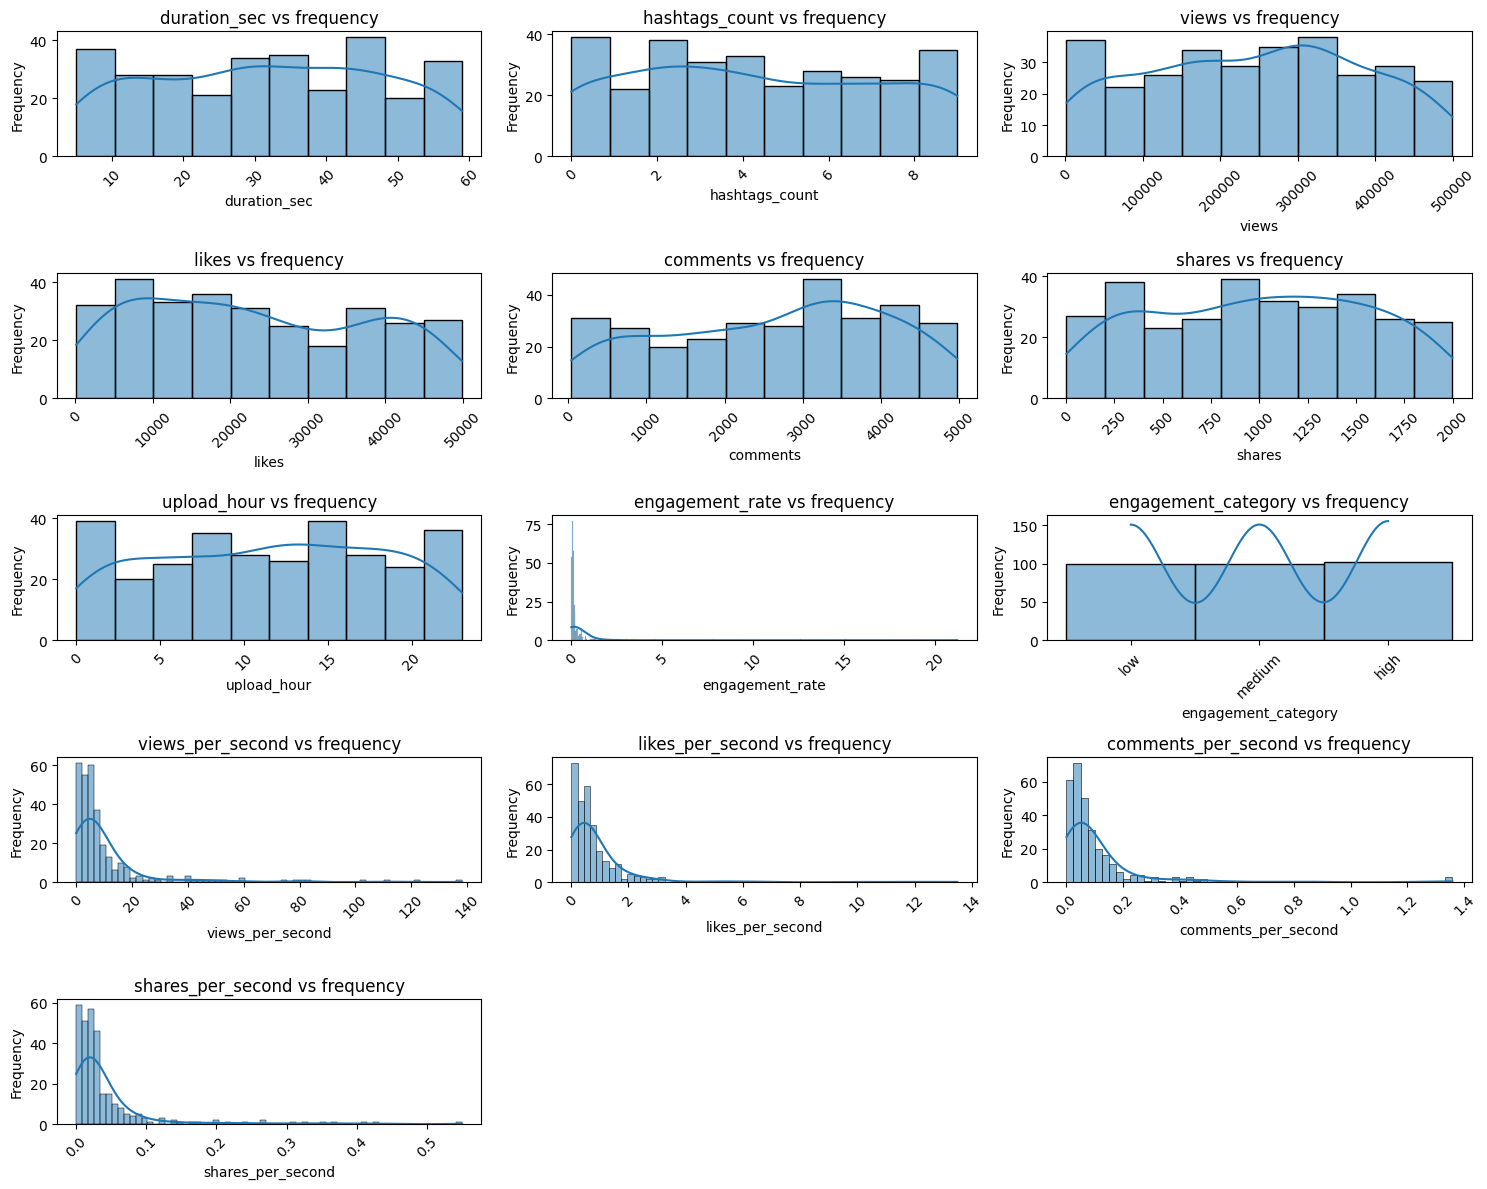

In [ ]:
def plot_histograms(df, columns, fig_size):
  fig_cols=3
  fig_rows=len(columns)//fig_cols+(1 if len(columns)%fig_cols>0 else 0)
  fig, axes=plt.subplots(fig_rows, fig_cols, figsize=fig_size)
  axes=axes.flatten()
  for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'{col} vs frequency')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)
  #remove empty plots
  for i in range(len(columns), len(axes)):
    fig.delaxes(axes[i])
  plt.tight_layout()
  plt.show()

columns=data.columns
columns=columns.drop(['video_id','title','category'], errors='ignore')
columns
plot_histograms(data, columns,(15,12))

In [ ]:
columns=data.columns
columns=columns.drop(['video_id','title','category','engagement_category'], errors='ignore')
data[columns].skew().abs()

,0
duration_sec,0.024779
hashtags_count,0.103547
views,0.042886
likes,0.180344
comments,0.213565
shares,0.048557
upload_hour,0.055975
engagement_rate,9.010165
views_per_second,4.122204
likes_per_second,5.191093


# All columns are roughly symmetric with |skew|<0.5, except columns: engagement_rate, likes_per_second, comments_per_second, shares_per_second, views_per_second are skewed features with |skew|>1. So, calculating logarthmic transformation on skewed features.

In [ ]:
data['log_engagement_rate']=np.log1p(data['engagement_rate'])
data['log_views_per_second']=np.log1p(data['views_per_second'])
data['log_likes_per_second']=np.log1p(data['likes_per_second'])
data['log_comments_per_second']=np.log1p(data['comments_per_second'])
data['log_shares_per_second']=np.log1p(data['shares_per_second'])

In [ ]:
columns=data.columns.drop(['video_id','title','category','engagement_category','engagement_rate','likes_per_second','comments_per_second','shares_per_second','views_per_second'], errors='ignore')
data[columns].skew().abs()

,0
duration_sec,0.024779
hashtags_count,0.103547
views,0.042886
likes,0.180344
comments,0.213565
shares,0.048557
upload_hour,0.055975
log_engagement_rate,4.742298
log_views_per_second,0.519253
log_likes_per_second,1.952982


In [ ]:
# Justification for no further log transformation

In [ ]:
data.describe()

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,engagement_rate,views_per_second,likes_per_second,comments_per_second,shares_per_second,log_engagement_rate,log_views_per_second,log_likes_per_second,log_comments_per_second,log_shares_per_second
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,31.730000,4.343333,245058.166667,23063.126667,2638.296667,999.576667,11.543333,0.430577,10.712189,0.924235,0.112081,0.042002,0.216087,1.914027,0.517961,0.096439,0.039304
std,16.042912,2.956562,141338.982093,14597.458220,1416.827287,564.410105,6.814414,1.753319,18.009997,1.561885,0.185449,0.068355,0.371283,0.962291,0.443689,0.129292,0.058551
min,5.000000,0.000000,1404.000000,109.000000,40.000000,2.000000,0.000000,0.003509,0.020526,0.004019,0.000725,0.000043,0.003503,0.020318,0.004010,0.000724,0.000043
25%,18.000000,2.000000,129620.500000,10342.000000,1445.750000,516.250000,6.000000,0.064102,2.630948,0.230293,0.032536,0.011678,0.062131,1.289461,0.207249,0.032018,0.011611
50%,32.000000,4.000000,255962.000000,21779.500000,2863.500000,988.000000,12.000000,0.106933,5.598424,0.546289,0.057108,0.022948,0.101593,1.886830,0.435858,0.055537,0.022688
75%,45.000000,7.000000,356805.000000,36706.500000,3761.000000,1463.750000,17.000000,0.215850,9.941436,0.968259,0.116125,0.040033,0.195443,2.392554,0.677147,0.109863,0.039252
max,59.000000,9.000000,499401.000000,49923.000000,4971.000000,1998.000000,23.000000,21.220085,138.190000,13.485278,1.358056,0.550278,3.100997,4.935840,2.673133,0.857837,0.438434


# EDA

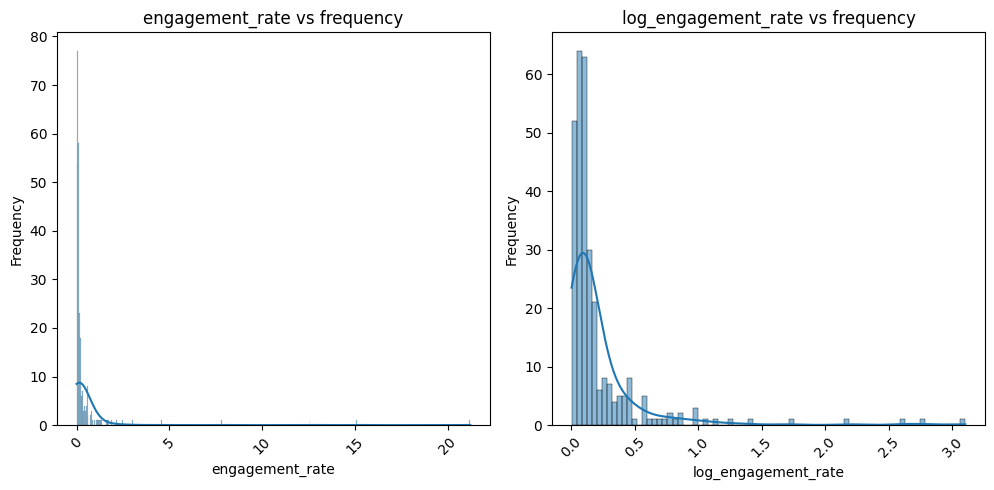

In [ ]:
plot_histograms(data, ['engagement_rate','log_engagement_rate'], (15,5))

In [ ]:
data_new=data.copy()
data_new['engagement_rate_pct']=data_new['engagement_rate']*100
data_new["er_cap"] = data_new["engagement_rate_pct"].clip(upper=data_new["engagement_rate_pct"].quantile(0.99))

# robust = data_new.groupby("category")["er_cap"].mean().sort_values(ascending=False)
cat_er=(data_new.groupby("category")
             .agg(
                 n=("video_id","count"),
                 mean_er=("er_cap","mean"),
                 median_er=("er_cap","median"),
                 std_er=("er_cap","std")
             )
             .sort_values("mean_er", ascending=False)
          )
# cat_er
rng = np.random.default_rng(42)
def bootstrap_ci(x, n_boot=5000, alpha=0.05):
    if len(x) < 5:
        return np.nan, np.nan
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return lo, hi

ci = (data_new.groupby("category")["engagement_rate_pct"]
        .apply(lambda s: pd.Series(bootstrap_ci(s), index=["ci_low","ci_high"]))
        .unstack()
     )
summary_ci = cat_er.join(ci)
summary_ci.sort_values("mean_er", ascending=False)

,n,mean_er,median_er,std_er,ci_low,ci_high
category,,,,,,
Lifestyle,42,54.076685,9.260133,166.365792,14.703527,205.498901
Education,53,39.858160,14.127487,77.220325,22.507325,63.168713
Travel,40,37.577015,8.489924,124.046993,12.646281,115.806964
Tech,55,34.436239,11.385110,106.626892,15.317646,105.441329
Food,57,32.469240,11.247123,55.511469,19.766850,48.075542
Comedy,53,14.216255,10.730237,12.180829,11.219900,17.754683


### Across 300 youtube shorts, the categories with highest average engagement rate are: Lifestyle, Education, and Travel, whereas lower engagement rates are: Comedy, Food, Tech.
### But lifestyle has a wide confidence interval(CI), indicating high variability/outliers.
### Comedy, however, has narrow CI, indicating consistent low mena engagement rate with higher certainity.

In [ ]:
def cat_to_num_convert(df, col_name, mapping_tuple, null_replacer_value):
  df[col_name]=df[col_name].astype(str).replace(mapping_tuple).fillna(null_replacer_value).astype(int)
  return df

# since upload_hour column has values {0,23} and they are cyclic by design, using their sin and cos transformations. This ensures that upload_hour=23 is nearer to 0 than 12.

In [ ]:
data['upload_hour_sin'] = np.sin(2 * np.pi * data['upload_hour'] / 24)
data['upload_hour_cos'] = np.cos(2 * np.pi * data['upload_hour'] / 24)
# data.drop('upload_hour', axis=1, inplace=True)
# data.info()

In [ ]:
#creating a copy of data with required columns

req_cols=data.columns.drop(['video_id','title','engagement_rate','likes_per_second','comments_per_second','shares_per_second','views_per_second', 'likes','comments','shares', 'views'], errors='ignore')
log_data=data[req_cols].copy()

categorical_columns=['category']
#converting engagement_category to numerical column
log_data=cat_to_num_convert(log_data, 'engagement_category', {'low':0, 'medium':1, 'high':2}, 3)

/tmp/ipython-input-4095634150.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col_name]=df[col_name].astype(str).replace(mapping_tuple).fillna(null_replacer_value).astype(int)


<Axes: >

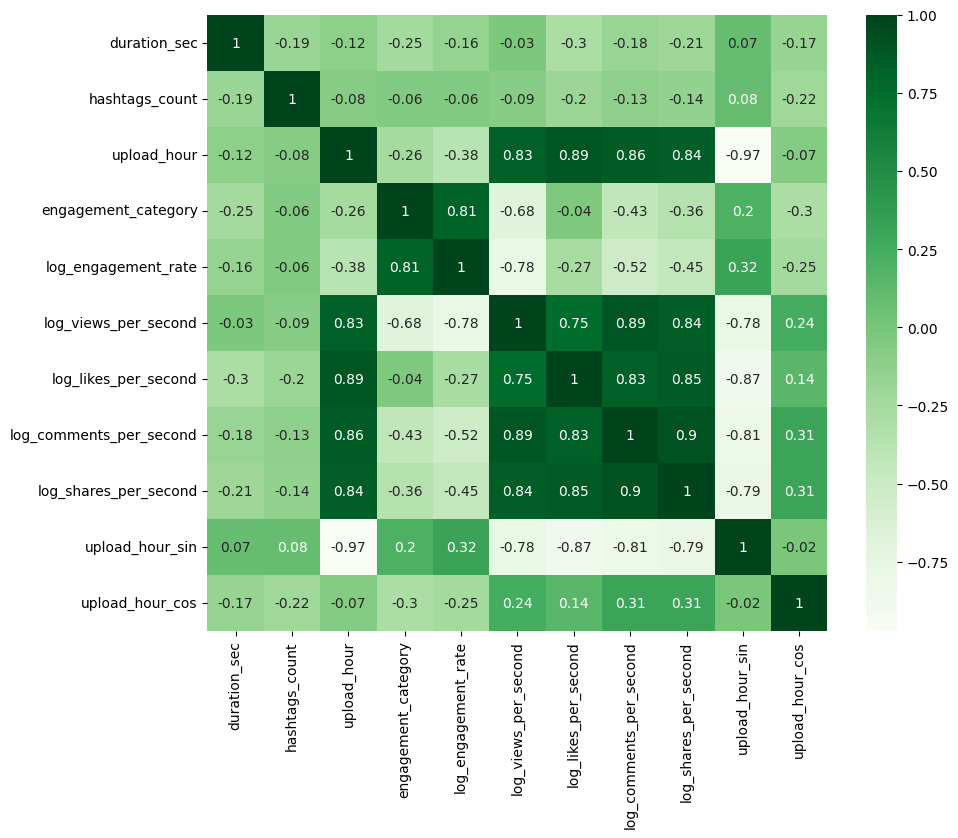

In [ ]:
#correlations
cor_log_data=log_data.drop('category', axis=1).corr().round(2)
# cor_log_data
correlations=cor_log_data.corr().round(2)#['engagement_category'].to_frame().sort_values(by='is_click',ascending=False).round(2)
correlations
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='Greens')

### 1. duration_sec and hashtag_counts have very weak or no linear relationship with any of the features, not even between them.
### 2. views has moderate to strong inverse linear relationship with engagement_category, and log_engagement_rate.
### 3. likes has moderate linear relationship with engagement_category. It also has moderately log_likes_per_second, because log_likes_per_second is a derived column from likes column
### 4. comments, and shares have weak or no linear relationship with any of other columns except log_comments_per_second, and log_shares_per_second respectively, because they are derived columns from these columns.
### 5. upload hour has moderate to strong related to derived features.
### 6. log_views_per_second has strong linear relation with log_comments_per_second.
### 7. log_comments_per_second has strong linear relation with log_shares_per_second.

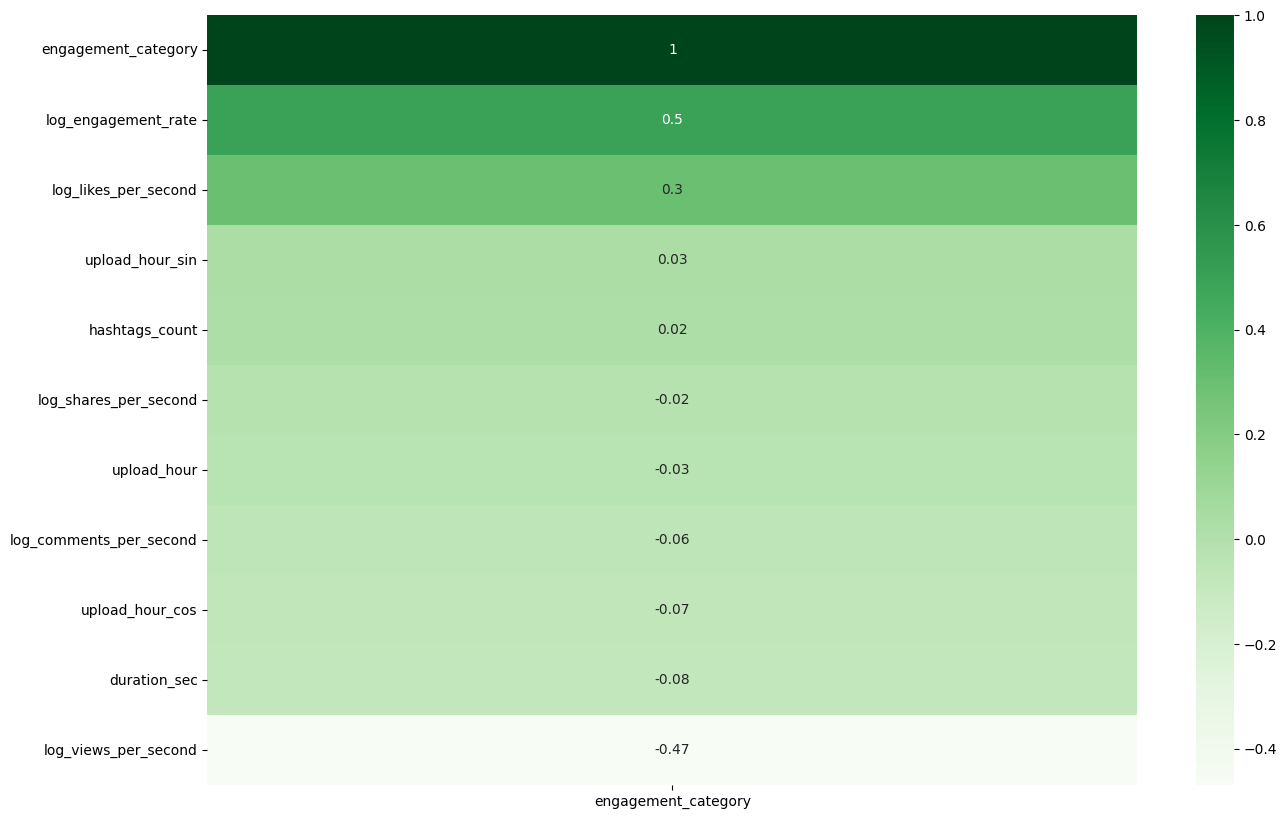

In [ ]:
def find_correlations_with_col(df, col_name):
  df=df.drop('category', axis=1).copy()
  correlations=df.corr()[col_name].to_frame().sort_values(by=col_name,ascending=False).round(2)
  return correlations

def heat_map_corr(corr):
  plt.figure(figsize=(15,10))
  sns.heatmap(corr, annot=True, cmap='Greens')
  plt.show()


heat_map_corr(find_correlations_with_col(log_data,'engagement_category'))

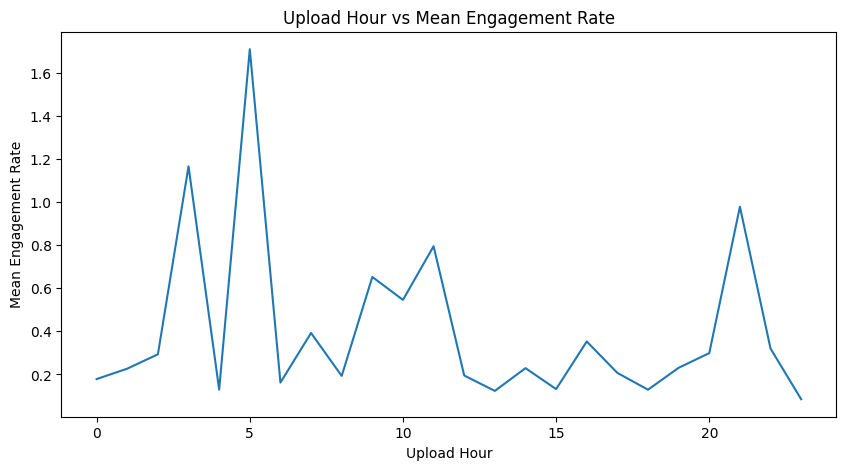

In [ ]:
# finding optimal hours for high engagement rate
hour_er=data.groupby('upload_hour').agg({'engagement_rate':'mean'})
# hour_er.sort_values(by='engagement_rate',ascending=False,inplace=True)
hour_er.reset_index(inplace=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=hour_er,x='upload_hour',y='engagement_rate')#, bins=range(24))
plt.title("Upload Hour vs Mean Engagement Rate")
plt.xlabel("Upload Hour")
plt.ylabel("Mean Engagement Rate")
plt.show()

### Top 3 Hours that have highest engagement rate are: 5, 21, and 3. Upload hour is just a representation of the hour not a numerical relation with engagement_rate.
### It is clear from analysis until now, above upload hours are the peak hours, so adding a time-based feature is_peak_hour

In [ ]:
# is_peak_hour feature derivation
data['is_peak_hour']=data['upload_hour'].apply(lambda x: 1 if x in [5,21,3] else 0)

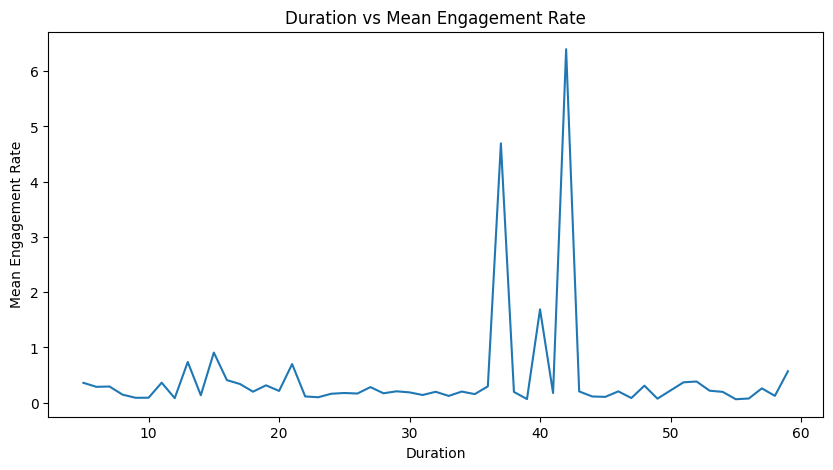

In [ ]:
# duration_sec vs engagement_rate
ds_er=data.groupby('duration_sec').agg({'engagement_rate':'mean'})
ds_er.reset_index(inplace=True)
plt.figure(figsize=(10,5))
sns.lineplot(data=ds_er,x='duration_sec',y='engagement_rate')
plt.title("Duration vs Mean Engagement Rate")
plt.xlabel("Duration")
plt.ylabel("Mean Engagement Rate")
plt.show()

### Youtube shorts with duration of 37 secs, 42 secs appear to have significantly high mean engagement rate.
### Shorts with 40 secs also has high mean engagement rate but not as compared to above mentioned durations.

# Building Model

In [ ]:
# remove outliers and scale data
def remove_outliers(df, num_cols):
  z_scores=stats.zscore(df[num_cols])
  outliers=np.abs(z_scores)>1.5
  filtered_rows=np.any(outliers,axis=1)
  cleaned_data=df[~filtered_rows].reset_index(drop=True)
  return cleaned_data

def scale_data(cleaned_data, num_columns, cat_columns):
  num_data=cleaned_data[num_columns]
  cat_data=cleaned_data[cat_columns]
  scaler=StandardScaler()
  scaled_num_data=pd.DataFrame(scaler.fit_transform(num_data),columns=num_columns)
  scaled_data = pd.concat([scaled_num_data,cat_data],axis=1)
  return scaled_data

In [ ]:
# RandomCV
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from scipy.stats import randint, uniform, loguniform
from sklearn.inspection import permutation_importance

def _get_feature_names_from_pipe(best_pipe):
    pre = best_pipe.named_steps["preprocess"]
    try:
        return pre.get_feature_names_out()
    except Exception:
        # fallback: generic names
        n = best_pipe.named_steps["model"].n_features_in_
        return np.array([f"feature_{i}" for i in range(n)])

def _extract_feature_importance(best_pipe, X, y, scoring, top_n=25, perm_repeats=10):
    preprocessor_step = best_pipe.named_steps["preprocess"]
    model = best_pipe.named_steps["model"]
    smote_step = best_pipe.named_steps["smote"]

    # Get feature names from the preprocessor output
    feature_names = preprocessor_step.get_feature_names_out()

    imp = None
    method = ""

    # 1) Logistic Regression -> abs(coef)
    if hasattr(model, "coef_"):
        coef = model.coef_
        imp = np.mean(np.abs(coef), axis=0) if coef.ndim == 2 else np.abs(coef)
        method = "coef_abs"

    # 2) Tree models -> feature_importances_
    elif hasattr(model, "feature_importances_"):
        imp = np.asarray(model.feature_importances_)
        method = "tree_importance"

    # 3) Anything else -> permutation importance
    else:
        # 1. Transform the original X using the preprocessor step
        X_preprocessed = preprocessor_step.transform(X)
        # Ensure X_preprocessed is dense before SMOTE and permutation_importance if it was sparse
        if hasattr(X_preprocessed, 'toarray'):
            X_preprocessed = X_preprocessed.toarray()

        print(f"DEBUG inside _extract_feature_importance (model: {best_pipe.named_steps['model'].__class__.__name__}):")
        print(f"  X_preprocessed shape before SMOTE: {X_preprocessed.shape}")
        print(f"  len(feature_names) from preprocessor: {len(feature_names)}")
        if hasattr(model, 'n_features_in_'):
            print(f"  Model n_features_in_: {model.n_features_in_}")

        # 2. Apply SMOTE to get the resampled data that the model was trained on
        X_resampled, y_resampled = smote_step.fit_resample(X_preprocessed, y)

        print(f"  X_resampled shape after SMOTE: {X_resampled.shape}")

        # 3. Run permutation importance using ONLY the model and the resampled, transformed data
        pi = permutation_importance(
            model, X_resampled, y_resampled,
            scoring=scoring,
            n_repeats=perm_repeats,
            random_state=42,
            n_jobs=-1
        )
        imp = np.asarray(pi.importances_mean)
        method = f"permutation_{perm_repeats}x"
        print(f"  len(imp) from permutation_importance: {len(imp)}")

    if len(feature_names) != len(imp):
        # This check is crucial. If it still fails, there's a deeper issue that needs investigation.
        raise ValueError(f"Feature name count ({len(feature_names)}) != importance count ({len(imp)})")

    imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": imp,
        "Method": [method] * len(feature_names)
    }).sort_values("Importance", ascending=False)

    return imp_df.head(top_n).reset_index(drop=True), imp_df

def models_Random_cv(df, k=10, n_iter=30):
  # X, y
  X = df.drop('engagement_category', axis=1).copy()
  y = df['engagement_category'].astype(int).copy()

  # columns
  cat_cols = ['category']
  num_cols = X.columns.drop(cat_cols, errors='ignore').tolist()

  # preprocessing
  preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', StandardScaler(), num_cols)
        ],
        remainder='drop'
  )

  # CV setup + scoring
  cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
  scoring = {
        'accuracy': 'accuracy',
        'f1_macro': make_scorer(f1_score, average='macro')
  }

  # models and grids
  models_and_dists = {
        "Logistic Regression": (
            LogisticRegression(max_iter=2000),
            {
                "model__C": loguniform(1e-2, 1e2),
                "model__class_weight": [None, "balanced"]
            }
        ),
        "Decision Tree": (
            DecisionTreeClassifier(random_state=42),
            {
                "model__max_depth": [None, 2, 3, 4, 5, 6, 8, 10],
                "model__min_samples_split": randint(2, 25),
                "model__min_samples_leaf": randint(1, 15),
                "model__criterion": ["gini", "entropy"],
                "model__max_features": [None, "sqrt", "log2"],
                "model__class_weight": [None, "balanced"]
            }
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=42),
            {
                "model__n_estimators": randint(150, 800),
                "model__max_depth": [None, 4, 5, 6, 8, 10],
                "model__min_samples_split": randint(2, 15),
                "model__min_samples_leaf": randint(1, 10),
                "model__max_features": ["sqrt", "log2"]
            }
        ),
        "Gradient Boosting": (
            GradientBoostingClassifier(random_state=42),
            {
                "model__n_estimators": randint(80, 500),
                "model__learning_rate": uniform(0.01, 0.19),  # 0.01 to 0.20
                "model__max_depth": randint(2, 6),
                "model__subsample": uniform(0.6, 0.4),       # 0.6 to 1.0
                "model__min_samples_split": randint(2, 15),
                "model__min_samples_leaf": randint(1, 10)
            }
        ),
        "AdaBoost": (
            AdaBoostClassifier(random_state=42),
            {
                "model__n_estimators": randint(50, 400),
                "model__learning_rate": uniform(0.2, 1.8)    # 0.2 to 2.0
            }
        ),
        "K-Nearest Neighbors": (
            KNeighborsClassifier(),
            {
                "model__n_neighbors": randint(3, 30),
                "model__weights": ["uniform", "distance"],
                "model__p": [1, 2]
            }
        ),
        "Gaussian Naive Bayes": (
            GaussianNB(),
            {
                "model__var_smoothing": loguniform(1e-10, 1e-6)
            }
        ),
        # "Support Vector Machine (Linear)": (
        # SVC(),
        # {
        #     "model__kernel": ["linear"],
        #     "model__C": loguniform(1e-2, 1e2),
        #     "model__class_weight": [None, "balanced"]
        # }
        # )
    }

  results = []
  cm_data = []
  roc_data = []
  importances_top = []
  importances_full = []
  perm_scoring = make_scorer(f1_score, average="macro")

  classes = np.sort(y.unique())
  n_classes = len(classes)

  for name, (model, param_dist) in models_and_dists.items():
        pipe = ImbPipeline(steps=[
            ("preprocess", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])

        search = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            random_state=42,
            verbose=0,
            refit='f1_macro' # Explicitly set refit to one of the scoring metrics
        )

        search.fit(X, y)
        best_pipe = search.best_estimator_

        top_imp, full_imp = _extract_feature_importance(
        best_pipe=best_pipe,
        X=X,
        y=y,
        scoring=perm_scoring,
        top_n=25,
        perm_repeats=10
        )
        top_imp.insert(0, "Model", name)
        full_imp.insert(0, "Model", name)

        importances_top.append(top_imp)
        importances_full.append(full_imp)

        y_pred_oof = cross_val_predict(
            best_pipe, X, y,
            cv=cv,
            method="predict",
            n_jobs=-1
        )
        cm = confusion_matrix(y, y_pred_oof, labels=classes)

        cm_data.append({
            "Model": name,
            "Labels": classes.tolist(),
            "Matrix": cm
        })

        # Requires predict_proba. (All current models support it.)
        y_proba_oof = cross_val_predict(
            best_pipe, X, y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1
        )

        overall_auc = roc_auc_score(
            y, y_proba_oof,
            multi_class="ovr",
            average="macro"
        )

        # Macro-average ROC curve
        y_bin = label_binarize(y, classes=classes)  # shape: (n_samples, n_classes)

        all_fpr = np.unique(np.concatenate([
            roc_curve(y_bin[:, i], y_proba_oof[:, i])[0] for i in range(n_classes)
        ]))

        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba_oof[:, i])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= n_classes

        roc_data.append({
            "Model": name,
            "FPR": all_fpr.tolist(),
            "TPR": mean_tpr.tolist(),
            "AUC_macro_ovr": float(overall_auc)
        })

        results.append({
            "Model": name,
            "Best_F1_macro": round(search.best_score_, 4),
            "Best_Params": search.best_params_,
            "OOF_ROC_AUC_macro_ovr": round(overall_auc, 4)
        })

  results_df = pd.DataFrame(results).sort_values(by="Best_F1_macro", ascending=False).reset_index(drop=True)
  cm_df = pd.DataFrame(cm_data)
  roc_df = pd.DataFrame(roc_data)
  importances_top_df = pd.concat(importances_top, ignore_index=True)
  importances_full_df = pd.concat(importances_full, ignore_index=True)

  return results_df, cm_df, roc_df, importances_top_df, importances_full_df

def pipeline_smote_Random_cv(df):
  y = df['engagement_category'].copy()
  X = df.drop('engagement_category', axis=1).copy()

  leakage_cols = ['likes', 'comments', 'shares', 'views', 'engagement_rate',
                    'likes_per_second', 'comments_per_second', 'shares_per_second',
                    'log_engagement_rate', 'log_views_per_second', 'log_likes_per_second',
                    'log_comments_per_second', 'log_shares_per_second']

  X = X.drop(columns=leakage_cols, errors='ignore')

  final_data = pd.concat([X, y], axis=1)

  # Run GridSearchCV for all models
  leaderboard, cm_data, roc_data, imp_top, imp_full = models_Random_cv(final_data, k=5, n_iter=40)
  return leaderboard, cm_data, roc_data, imp_top, imp_full


In [ ]:
#SMOTE with Random_CV
start_time = time.perf_counter()

random_cv_results, cm_data, roc_data, imp_top, imp_full  = pipeline_smote_Random_cv(log_data)

end_time = time.perf_counter()
time_taken_smote=end_time - start_time

DEBUG inside _extract_feature_importance (model: KNeighborsClassifier):
  X_preprocessed shape before SMOTE: (300, 11)
  len(feature_names) from preprocessor: 11
  Model n_features_in_: 11
  X_resampled shape after SMOTE: (306, 11)
  len(imp) from permutation_importance: 11
DEBUG inside _extract_feature_importance (model: GaussianNB):
  X_preprocessed shape before SMOTE: (300, 11)
  len(feature_names) from preprocessor: 11
  Model n_features_in_: 11
  X_resampled shape after SMOTE: (306, 11)
  len(imp) from permutation_importance: 11


In [ ]:
print("Models' performances with smote and Random CV")
print(f"Training time = {time_taken_smote:0.2f}")
random_cv_results.sort_values(by='Best_F1_macro',ascending=False)
random_cv_results

Models' performances with smote and Random CV
Training time = 584.83


,Model,Best_F1_macro,Best_Params,OOF_ROC_AUC_macro_ovr
0,K-Nearest Neighbors,0.3747,"{'model__n_neighbors': 6, 'model__p': 2, 'mode...",0.5237
1,Logistic Regression,0.3592,"{'model__C': 0.06080390190296603, 'model__clas...",0.5044
2,AdaBoost,0.3554,"{'model__learning_rate': 0.7332923102673483, '...",0.5316
3,Decision Tree,0.3530,"{'model__class_weight': None, 'model__criterio...",0.5126
4,Gaussian Naive Bayes,0.3473,{'model__var_smoothing': 3.1489116479568554e-09},0.5135
5,Random Forest,0.3448,"{'model__max_depth': 4, 'model__max_features':...",0.5045
6,Gradient Boosting,0.3367,"{'model__learning_rate': 0.06716687886518624, ...",0.4805


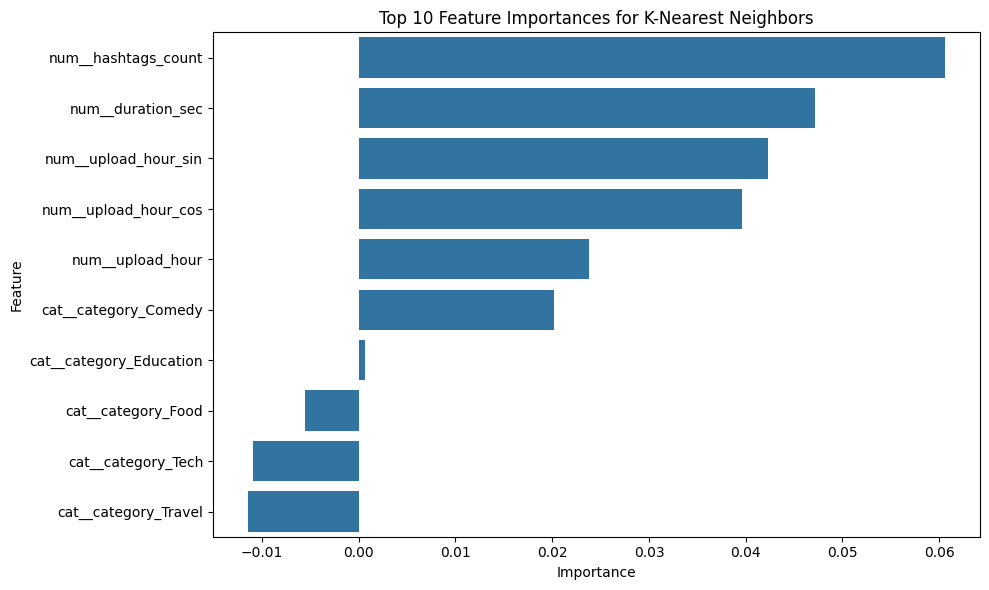

In [ ]:
# Get the best model name
best_model_name = random_cv_results.iloc[0]['Model']

# Filter imp_top for the best model
best_model_imp_top = imp_top[imp_top['Model'] == best_model_name]

# Plotting the top feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=best_model_imp_top.head(10))
plt.title(f'Top 10 Feature Importances for {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
def plot_confusion_matrix(cm, labels, model_name, ax):
    # Create an image of the confusion matrix
    im = ax.imshow(cm, interpolation='nearest')

    # Add a colorbar to the plot
    ax.figure.colorbar(im, ax=ax)

    # Set axis labels and title
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=labels, yticklabels=labels,
           title=f'Confusion Matrix for {model_name}',
           ylabel='True label',
           xlabel='Predicted label')

    # Add text annotations for each cell in the matrix
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="w")

In [ ]:
def plot_confusion_matrices(cm_df, columns, rows):
    num_models = len(cm_df)
    actual_rows = (num_models + columns - 1) // columns
    fig, axes = plt.subplots(actual_rows, columns, figsize=(15, 10))

    axes = axes.flatten()

    for i, entry_row in cm_df.iterrows():
        model_name = entry_row['Model']
        cm = entry_row['Matrix']

        # Ensure cm is a numpy array if it's not already
        if not isinstance(cm, np.ndarray):
            cm = np.array(cm)

        class_labels = ['low', 'medium', 'high']

        plot_confusion_matrix(cm, class_labels, model_name, axes[i])

    for i in range(num_models, actual_rows * columns):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

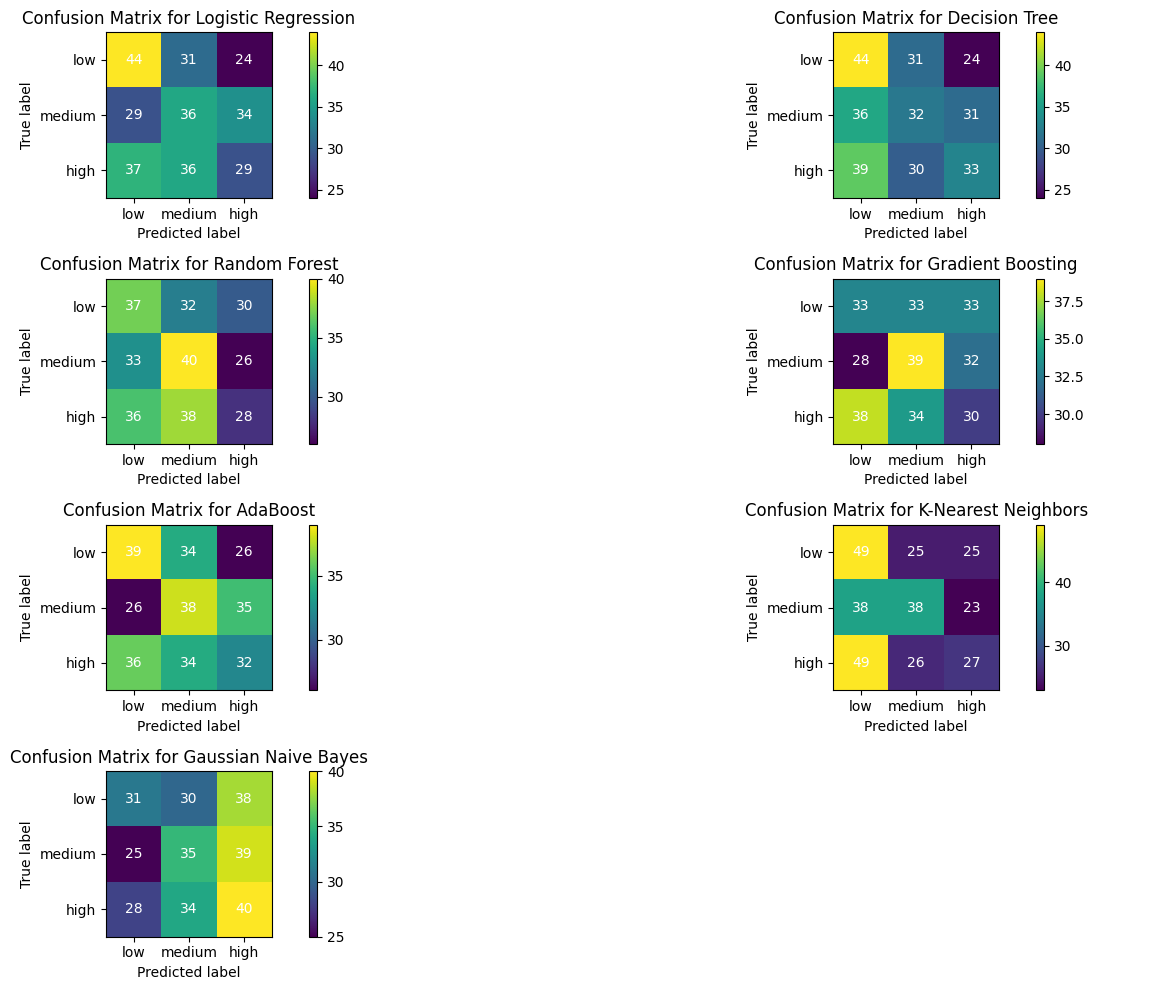

In [ ]:
plot_confusion_matrices(cm_data,columns=2,rows=4)

In [ ]:
def plot_roc_curve(roc_data):
    plt.figure(figsize=(8, 6))
    plt.title('Receiver Operating Characteristic (ROC) Curve')

    for i, model_data in roc_data.iterrows():
        model_name = model_data['Model']
        fpr = model_data['FPR']
        tpr = model_data['TPR']
        # Corrected key from 'AUC' to 'AUC_macro_ovr'
        auc = model_data['AUC_macro_ovr']

        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

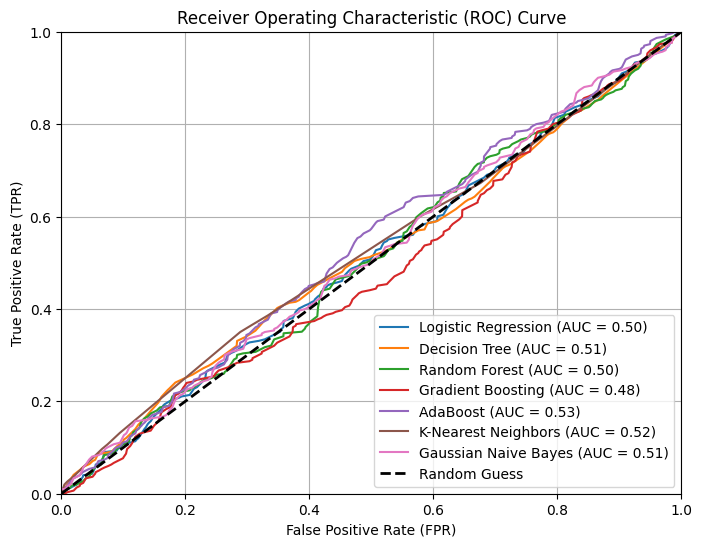

In [ ]:
plot_roc_curve(roc_data)

### ROC-AUC curve is close to 0.5 bacuase the target variable is derived from engagement metrics that intentionally excluded to avoid leakage, leaving only metadata features. As the model struggles with probability ranking, which is expected and confirms that the evaluation is leakage-free.

### **Business Questions and Answers**

### Q1. **Calculate the Engagement Rate for all Shorts and categorize performance into Low, Medium, and High tertiles. What is the distribution of the target variable, and does it suggest any class imbalance challenges?**

### Ans. *Engagement rate is computed as (likes+comments+shares)/views and binned it to bins(low, medium, high) based on 33rd and 66th percentile thresholds. The resulting distribution is low=102, medium=99, high=99, which is approximately balanced. Therefore, class imbalance is not a major concern here, and we do not expect a bias towards any class. Minor deviations from perfectly equal counts is expected due to tied engagement rates near quantile boundaries. The modelling challenge is likely class overlap rather than class imbalance.*

### Q2. **Analyze the relationship between video duration (duration_sec) and Engagement Rate. Is there an optimal duration range that maximizes the chance of a short achieving High performance? What is the model's reliance on this feature?**

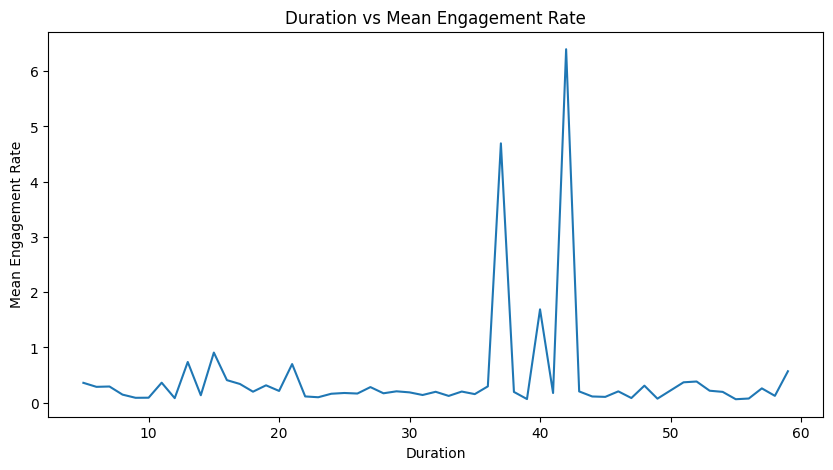

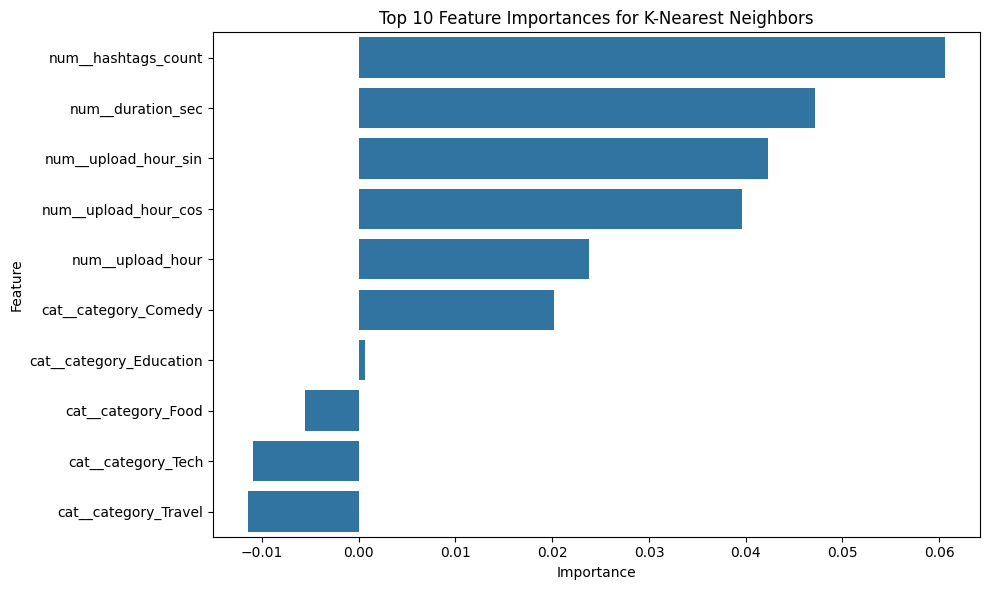

### *From exploratory analysis, engagement rate does not montonically increase or decrease with duration(secs). While there are localized spikes(e.g., 37 to 42 secs), engagement rates also vary widely across many other durations. This suggests duration alone cannot give single optimal range, and the best duration might depend on other factors like (hook strength, content relevance, category, upload time, etc.)*
### *Some mid-level durations might perform well, but variability is high. So duration is a lever to optimize through testing rather than a fixed rule.*
### *Video duration has permutation importance of 0.05 meaning permuting this feature can reduce f1_macro by 0.05 units(~13% relative drop), indicating meaningful driver in predictive model.*

### Q3. **Analyze the influence of the upload_hour on average Engagement Rate. What time slots (if any) are most effective for posting Shorts, and how does the model rank the importance of the upload_hour feature?**

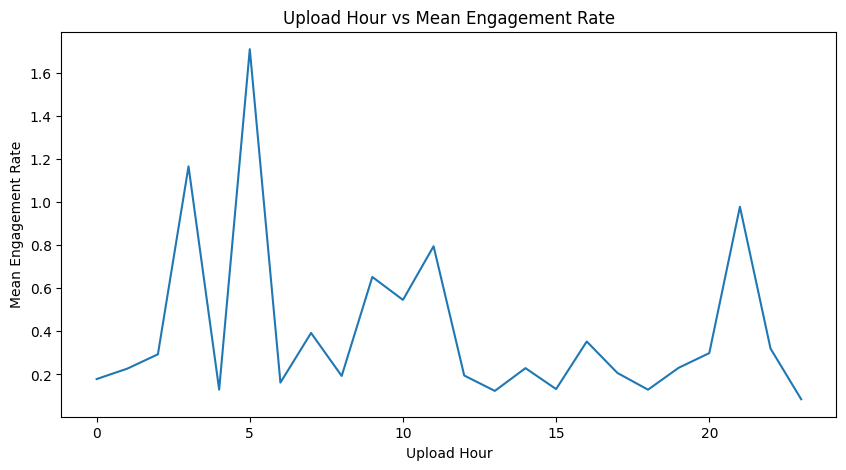

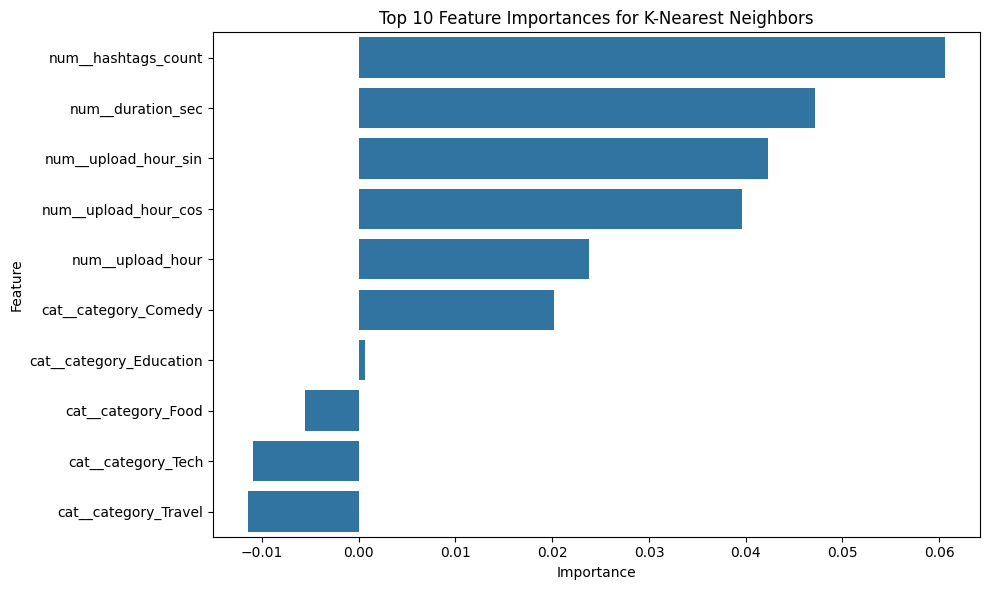

### Ans. *Influence of Upload hour on engagement rate: Aggregating engagement rate by upload hour shows that hours 3,5, and 21 have significantly higher mean engagement rate. However, it should be treated cautiously because the dataset is small(~300).*
### *From feature importances, we learn that upload hour(cyclical encoded) have permutation importances of greater than 0.04. This indicates noticable reliance on posting on time of the day. So, engagement rate is moderately dependent on upload hour.*
### *Model ranks upload_hour(cyclical encoded: sin and cos) in 3rd and 4th in permutation importance. Indicating, posting hour is a significant indicator of performance.*

### Q4. **Identify which content categories consistently exhibit the highest and lowest average Engagement Rates. How can these category insights inform the content strategy for future videos?**

In [ ]:
summary_ci.sort_values("mean_er", ascending=False)

,n,mean_er,median_er,std_er,ci_low,ci_high
category,,,,,,
Lifestyle,42,54.076685,9.260133,166.365792,14.703527,205.498901
Education,53,39.858160,14.127487,77.220325,22.507325,63.168713
Travel,40,37.577015,8.489924,124.046993,12.646281,115.806964
Tech,55,34.436239,11.385110,106.626892,15.317646,105.441329
Food,57,32.469240,11.247123,55.511469,19.766850,48.075542
Comedy,53,14.216255,10.730237,12.180829,11.219900,17.754683


### *Across the 300 youtube shorts, the categories with highest average engagement rate are: Lifestyle, Education, and Travel, whereas lower engagement rates are: Comedy, Food, Tech.*
### *Since engagement rate is heavily tailed(very large std and wide Confidence Intervals(CI)), so category comparisions based on mean are highly distorted by low-view outliers. We therefore interpret 'consisitently high' categories using CI width.*
### *But lifestyle has a wide CI, indicating high variability/outliers.*
### *Comedy, however, has narrow CI, indicating consistent low mean engagement rate with higher certainity.*
### *Among the top performers, Education is a most reliable category, since it has relatively high mean(39.85) with much tighter CI(22 to 63), giving stable advantage than others.*
### *Content strategy needs to focus more on educative youtube shorts that has high reliable engagement rate.*

### Q5. **Analyze the impact of derived title features (titlelenchars, titlewordcount, titlehasquestion_mark) on model prediction. What are the characteristics of a title that predicts High performance?**

### Ans. *In the dataset, Title follows a uniform template "Short Video \#x" format, meaning there is minimal linguistic variability.As a result, textual features like title_len_chars, title_word_count, and title_has_question_mark show zero contribution to engagement rate.*
### *Future: Better title data. High performing shorts often have better title hooks(content, emotion, curiosity, benefit), but validating this would require collecting real, varied titles, and using rich text features(keywords, punctuations, hooks) *

### Q6. **Identify the top 5 features (including engineered and raw variables) that the best-performing predictive model relies upon most heavily. Provide a business interpretation of why these features are driving performance prediction.**

### Ans. *Top 5 features that the model relies on:*
### 1. *Hashtag counts: reduces f1_macro by 0.06(~11% drop), stronger hashtag usage can lead to discoverability and topic matching.*
### 2. *Video duration(importances=0.047), values closer to observed durations(42, 37, 41 secs) can help get higher completion/replay. It can be a proxy for video completion and viewer retention.*
### 3,4. *Upload Hour(engineered cyclic time)(importances=0.043, 0.039): These features encode upload hour cyclically (so 23:00 is close to 00:00). Upload hour impacts audience availability, competitive density, and how quickly early engagement accumilates. Early engagement timing infludences recommendation momentum.*
### 5. *Upload Hour(raw)(importances=0.024): weaker duplicate of engineered cyclical feature. It confirms that upload hour drives engagement.*

### Q7. **Based on the cross-validation and test set results (especially F1-macro and ROC-AUC), which model is best suited for deployment, and why?**

In [ ]:
print("Models' performances with smote and Random CV")
print(f"Training time = {time_taken_smote:0.2f}")
random_cv_results.sort_values(by='Best_F1_macro',ascending=False)
random_cv_results

Models' performances with smote and Random CV
Training time = 584.83


,Model,Best_F1_macro,Best_Params,OOF_ROC_AUC_macro_ovr
0,K-Nearest Neighbors,0.3747,"{'model__n_neighbors': 6, 'model__p': 2, 'mode...",0.5237
1,Logistic Regression,0.3592,"{'model__C': 0.06080390190296603, 'model__clas...",0.5044
2,AdaBoost,0.3554,"{'model__learning_rate': 0.7332923102673483, '...",0.5316
3,Decision Tree,0.3530,"{'model__class_weight': None, 'model__criterio...",0.5126
4,Gaussian Naive Bayes,0.3473,{'model__var_smoothing': 3.1489116479568554e-09},0.5135
5,Random Forest,0.3448,"{'model__max_depth': 4, 'model__max_features':...",0.5045
6,Gradient Boosting,0.3367,"{'model__learning_rate': 0.06716687886518624, ...",0.4805


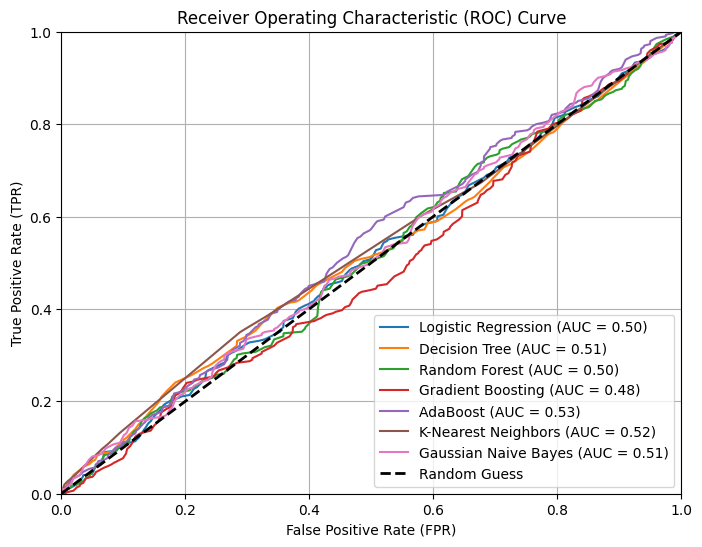

### Ans. *KNN is the best model based on F1-macro, but given AUC=0.52 curves near random, the model's discriptive power is weak. I would deploy it only as a baseline descision-support model(not for high stakes automation), and prioritize feature improvements+evaluation on truw holdout test set. If we need a production-friendly model with similar performance, Logistic Regression is a strong alternative dues to high F1-macro score(=0.359) and also it's simplicity, low-latency inteference, and stability.*

### Q8. **Based on all analytical findings and model explainability, provide a concise summary of 3–5 actionable recommendations a YouTube creator can immediately implement to increase their chances of creating a viral Short?**

### Ans. *Based on model explainability(from best model: KNN with f1_macro=0.37 and roc_auc=0.52), a youtube shorts creator can implement these strategies:*
### 1. *Hashtag relevancy: Hashtag emerged as the strongest driver in the model, indicating discoverability and tpoic matching significantly effect engagement. Prioritize topic-specific tags over generic ones, and A/B test small changes on hashtga to identify the sweet spot.*
### 2. *Shorts Duration optimization: Duration was a top predictor, denoting completion and replay behavior matter. Create tighter edits and test 2-3 duration bands (25-30, 30-35, 35-45) instead of random lengths to find what your audience finishes and replays.*
### 3. *Strategic posting of shorts: Upload hour showed meaningful model reliance, implyig that audience density and availability drive engagement. Identify best windows(might be early hours of the day), and consistently post on these hours rather than random posting.*
### 4. *Lean into more reliable engagement categories: Education has shown stable-high performance in shorts, while comedy lower. An ideal strategy would be to focus on education shorts and rely on lifestyle/travel/food as experimentation playgrounds rather than your main growth engines.*
### 5. *Treat Title as "unknown"  in this dataset: Title is not a strong feature, so not a level to optimize strategy. Instead focus on above points, while collecting better titles next time, to gain engagement.*

In [ ]:
import time
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# for CV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

def run_model_with_smote(df, model, name):
  cat_cols=['category']
  # The original num_cols definition was problematic if 'category' was still in df
  # We should ensure x does not have 'category' when num_cols are defined for the preprocessor
  # For consistency with the fix below, numerical columns will be handled by the pipeline_smote function

  x=df.drop('engagement_category', axis=1)
  y=df['engagement_category'].astype(int) # Explicitly cast y to int here
  x_train, x_test, y_train, y_test = train_test_split(x,y,stratify=y, test_size=0.2, random_state=42)

  smote=SMOTE(random_state=42)

  # The preprocessor needs to know which columns are numerical after dropping 'engagement_category' and before one-hot encoding 'category'
  # So, dynamically determine numerical columns for the preprocessor based on the current x_train columns, excluding 'category'
  current_num_cols = x_train.columns.drop(cat_cols, errors='ignore').tolist()

  preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', current_num_cols)
    ])
  model_pipeline=Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', model)])

  # SMOTE with Pipeline and ColumnTransformer
  # Step 1: Preprocess x_train and x_test
  x_train_processed = preprocessor.fit_transform(x_train)
  x_test_processed = preprocessor.transform(x_test)

  # Step 2: Apply SMOTE to the processed training data
  x_train_sampled, y_train_sampled = smote.fit_resample(x_train_processed, y_train)

  # Step 3: Train the model on SMOTE-resampled data
  model.fit(x_train_sampled, y_train_sampled)

  # Step 4: Get predictions from the model on preprocessed test data
  y_pred_proba = model.predict_proba(x_test_processed)

  return y_pred_proba,y_test

def evaluate_model(y_true, y_pred_proba):
    y_pred = np.argmax(y_pred_proba, axis=1)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)
    return accuracy, precision, recall, f1, cm

def models(df):
    results = []
    cm_data = []
    roc_data = []
    models_dict = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Gradient Boosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "Support Vector Machine": SVC(probability=True)
    }

    for name, model in models_dict.items():
        predictions_proba, y_test = run_model_with_smote(df, model, name)
        accuracy, precision, recall, f1, cm = evaluate_model(y_test, predictions_proba)

        overall_roc_auc = roc_auc_score(y_test, predictions_proba, multi_class='ovr')
        n_classes = predictions_proba.shape[1]
        y_test_binarized = label_binarize(y_test, classes=np.arange(n_classes))

        all_fpr = np.unique(np.concatenate([roc_curve(y_test_binarized[:, i], predictions_proba[:, i])[0] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], predictions_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr, tpr)
        mean_tpr /= n_classes

        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1
        })
        cm_data.append({
            "Model": name,
            "Matrix": cm
        })
        roc_data.append({
            "Model": name,
            "FPR": all_fpr.tolist(),
            "TPR": mean_tpr.tolist(),
            "AUC": overall_roc_auc
        })

    results_df = pd.DataFrame(results).round(4).sort_values(by="Accuracy", ascending=False)
    return results_df, cm_data, roc_data

def pipeline_smote(data):
    y = data['engagement_category'].copy()
    X = data.drop('engagement_category', axis=1).copy()

    # Fix: Correctly get numerical features by dropping 'category' from X.columns
    # Identified columns that cause data leakage and should be dropped.
    leakage_cols = ['likes', 'comments', 'shares', 'views', 'upload_hour', 'engagement_rate',
                    'likes_per_second', 'comments_per_second', 'shares_per_second',
                    'log_engagement_rate', 'log_views_per_second', 'log_likes_per_second',
                    'log_comments_per_second', 'log_shares_per_second']

    # Drop leakage columns from X
    X = X.drop(columns=leakage_cols, errors='ignore')
    # print(X.columns.tolist())

    numerical_features_for_processing = X.columns.drop('category', errors='ignore').tolist()

    combined_data_for_outliers = pd.concat([X, y.rename('engagement_category')], axis=1)

    cleaned_combined_data = remove_outliers(combined_data_for_outliers, numerical_features_for_processing)

    y_processed = cleaned_combined_data['engagement_category']
    X_processed = cleaned_combined_data.drop('engagement_category', axis=1)

    # Identify numerical and categorical columns in X_processed
    cols_to_scale = X_processed.select_dtypes(include=np.number).columns.tolist()
    cols_not_to_scale = X_processed.select_dtypes(exclude=np.number).columns.tolist()

    scaler = StandardScaler()
    scaled_numerical_parts = pd.DataFrame(scaler.fit_transform(X_processed[cols_to_scale]), columns=cols_to_scale, index=X_processed.index)
    # Ensure `category` column is preserved and aligned
    scaled_X = pd.concat([scaled_numerical_parts, X_processed[cols_not_to_scale]], axis=1)

    final_data_for_models = pd.concat([scaled_X, y_processed.reset_index(drop=True)], axis=1)

    performance, cm_data, roc_data = models(final_data_for_models)

    return performance, cm_data, roc_data

def models_cv(df, k=5):
    # X, y
    X = df.drop('engagement_category', axis=1).copy()
    y = df['engagement_category'].astype(int).copy()

    # columns
    cat_cols = ['category']
    num_cols = X.columns.drop(cat_cols, errors='ignore').tolist()

    # preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', StandardScaler(), num_cols)
        ],
        remainder='drop'
    )

    # CV setup + scoring
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': make_scorer(f1_score, average='macro')
    }

    # your models
    models_dict = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Gradient Boosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Support Vector Machine": SVC(probability=True)
    }

    results = []

    for name, model in models_dict.items():
        pipe = ImbPipeline(steps=[
            ('preprocess', preprocessor),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])

        cv_out = cross_validate(
            pipe, X, y,
            cv=cv,
            scoring=scoring,
            return_train_score=False
        )

        acc_mean = cv_out['test_accuracy'].mean()
        acc_std  = cv_out['test_accuracy'].std()

        f1_mean  = cv_out['test_f1_macro'].mean()
        f1_std   = cv_out['test_f1_macro'].std()

        results.append({
            "Model": name,
            "Accuracy (mean±std)": f"{acc_mean:.4f} \u00b1 {acc_std:.4f}",
            "F1-macro (mean\u00b1std)": f"{f1_mean:.4f} \u00b1 {f1_std:.4f}",
            "Accuracy_mean": round(acc_mean, 4),
            "F1_macro_mean": round(f1_mean, 4),
        })

    results_df = pd.DataFrame(results).sort_values(by="F1_macro_mean", ascending=False)
    # optional: drop helper columns
    results_df = results_df.drop(columns=["Accuracy_mean", "F1_macro_mean"])
    return results_df

def pipeline_smote_cv(df):
  # FIX: Use the 'df' parameter instead of the global 'data' variable
  y = df['engagement_category'].copy()
  X = df.drop('engagement_category', axis=1).copy()

  leakage_cols = ['likes', 'comments', 'shares', 'views', 'engagement_rate',
                    'likes_per_second', 'comments_per_second', 'shares_per_second',
                    'log_engagement_rate', 'log_views_per_second', 'log_likes_per_second',
                    'log_comments_per_second', 'log_shares_per_second']

  X = X.drop(columns=leakage_cols, errors='ignore')

  final_data_for_models = pd.concat([X, y], axis=1)

  # Run K-fold CV and return mean\u00b1std metrics
  results_df = models_cv(final_data_for_models, k=5)
  return results_df

In [ ]:
from sklearn.model_selection import GridSearchCV
def models_Grid_cv(df, k=5):
  # X, y
  X = df.drop('engagement_category', axis=1).copy()
  y = df['engagement_category'].astype(int).copy()

  # columns
  cat_cols = ['category']
  num_cols = X.columns.drop(cat_cols, errors='ignore').tolist()

  # preprocessing
  preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', StandardScaler(), num_cols)
        ],
        remainder='drop'
  )

  # CV setup + scoring
  cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
  scoring = {
        'accuracy': 'accuracy',
        'f1_macro': make_scorer(f1_score, average='macro')
  }

  # models and grids
  models_and_grids = {
        "Logistic Regression (strong tune)": (
            LogisticRegression(solver="saga"),
            {
                "model__penalty": ["l1", "l2", "elasticnet"],
                "model__C": [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100],
                "model__l1_ratio": [0.05, 0.1, 0.2, 0.35, 0.5, 0.65, 0.8, 0.9, 0.95],
                "model__class_weight": [None, "balanced"],
                "model__multi_class": ["ovr", "multinomial"],
                "model__tol": [1e-3, 1e-4, 1e-5]
            }
        ),
        "Decision Tree": (
            DecisionTreeClassifier(random_state=42),
            {
                "model__max_depth": [2, 3, 4, 5, 6, 8, None],
                "model__min_samples_leaf": [1, 2, 4, 6, 10],
                "model__min_samples_split": [2, 5, 10, 15],
                "model__criterion": ["gini", "entropy"],
                "model__class_weight": [None, "balanced"]
            }
        ),
        "Random Forest": (
            RandomForestClassifier(random_state=42),
            {
                "model__n_estimators": [200, 500, 800],
                "model__max_depth": [3, 4, 5, 6, 8, None],
                "model__min_samples_leaf": [1, 2, 4, 8, 12],
                "model__min_samples_split": [2, 5, 10, 20],
                "model__max_features": ["sqrt", "log2"],
                "model__class_weight": [None, "balanced"]
            }
        ),
        # "Gradient Boosting": (
        #     GradientBoostingClassifier(random_state=42),
        #     {
        #         "model__n_estimators": [100, 200, 300],
        #         "model__learning_rate": [0.03, 0.05, 0.1],
        #         "model__max_depth": [2, 3, 4],
        #         "model__subsample": [0.8, 1.0]
        #     }
        # ),
        "AdaBoost": (
            AdaBoostClassifier(
                estimator=DecisionTreeClassifier(random_state=42),
                random_state=42
            ),
            {
                "model__estimator__max_depth": [1, 2, 3],
                "model__n_estimators": [50, 100, 200],
                "model__learning_rate": [0.1, 0.3, 0.5, 1.0]
            }
        ),
        "K-Nearest Neighbors": (
            KNeighborsClassifier(),
            {
                "model__n_neighbors": [3, 5, 7, 9, 11],
                "model__weights": ["uniform", "distance"],
                "model__p": [1, 2]  # 1=Manhattan, 2=Euclidean
            }
        ),
        "Gaussian Naive Bayes": (
            GaussianNB(),
            {
                "model__var_smoothing": [1e-9, 1e-8, 1e-7]
            }
        ),
        # "Support Vector Machine (Linear)": (  #using linear SVC since dataset is ~300 and reduces overfitting
        #     SVC(),
        #     {
        #         "model__kernel": ["linear"],
        #         "model__C": [0.01, 0.1, 1, 10, 100],
        #         "model__class_weight": [None, "balanced"]
        #     }
        # )
    }

  results = []

  for name, (model, param_grid) in models_and_grids.items():
        pipe = ImbPipeline(steps=[
            ("preprocess", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ])

        search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=scoring,
            cv=cv,
            n_jobs=-1,
            verbose=0,
            refit='f1_macro' # Explicitly set refit to one of the scoring metrics
        )

        search.fit(X, y)

        results.append({
            "Model": name,
            "Best_F1_macro": round(search.best_score_, 4),
            "Best_Params": search.best_params_
        })

  results_df = pd.DataFrame(results).sort_values(by="Best_F1_macro", ascending=False)
  # No need to drop 'Accuracy_mean' or 'F1_macro_mean' as they are not created here
  return results_df

def pipeline_smote_Grid_cv(df):
  y = df['engagement_category'].copy()
  X = df.drop('engagement_category', axis=1).copy()

  leakage_cols = ['likes', 'comments', 'shares', 'views', 'engagement_rate',
                    'likes_per_second', 'comments_per_second', 'shares_per_second',
                    'log_engagement_rate', 'log_views_per_second', 'log_likes_per_second',
                    'log_comments_per_second', 'log_shares_per_second']

  X = X.drop(columns=leakage_cols, errors='ignore')

  final_data = pd.concat([X, y], axis=1)

  # Run GridSearchCV for all models
  leaderboard = models_Grid_cv(final_data, k=5)
  return leaderboard

In [ ]:
# #SMOTE
# start_time = time.perf_counter()

# performance, cm_data, roc_data = pipeline_smote(log_data)

# end_time = time.perf_counter()
# time_taken_smote=end_time - start_time
# print("Models' performances with smote")
# print(f"Training time = {time_taken_smote:0.2f}")
# performance.sort_values(by='F1 Score',ascending=False)

In [ ]:
# #SMOTE with CV
# start_time = time.perf_counter()

# cv_results = pipeline_smote_cv(log_data)

# end_time = time.perf_counter()
# time_taken_smote=end_time - start_time
# print("Models' performances with smote and CV")
# print(f"Training time = {time_taken_smote:0.2f}")
# cv_results.sort_values(by='F1-macro (mean±std)',ascending=False)

In [ ]:
# #SMOTE with GRID_CV
# start_time = time.perf_counter()

# grid_cv_results = pipeline_smote_Grid_cv(log_data)

# end_time = time.perf_counter()
# time_taken_smote=end_time - start_time

In [ ]:
# print("Models' performances with smote and Grid CV")
# print(f"Training time = {time_taken_smote:0.2f}")
# grid_cv_results.sort_values(by='Best_F1_macro',ascending=False)
# grid_cv_results